In [145]:
from skimage.color import rgb2gray
from skimage import filters, morphology
import matplotlib.pyplot as plt
import numpy as np
import imageio
from scipy import ndimage as ndi
import pandas as pd
import math
from skimage.measure import label, regionprops, regionprops_table
from skimage.draw import ellipse
from matplotlib.colors import ListedColormap

<ipython-input-146-61f4781299fc>:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread('/content/sample_data/genital-herpes-simplex-6-transformed.jpeg')


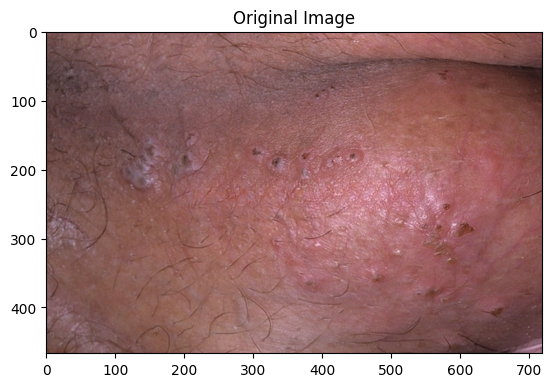

In [146]:
im = imageio.imread('/content/sample_data/genital-herpes-simplex-6-transformed.jpeg')
plt.imshow(im)
plt.title("Original Image")
plt.show()

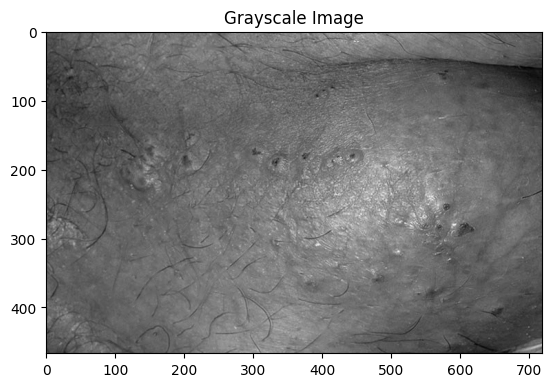

In [147]:
grayscale = rgb2gray(im)
plt.imshow(grayscale, cmap='gray')
plt.title("Grayscale Image")
plt.show()

In [148]:
grayscale_uint8 = (grayscale * 255).astype('uint8')
threshold = filters.threshold_otsu(grayscale_uint8)

print(f"Threshold: {threshold}")

Threshold: 106


In [149]:
phase_separation = grayscale_uint8 < threshold

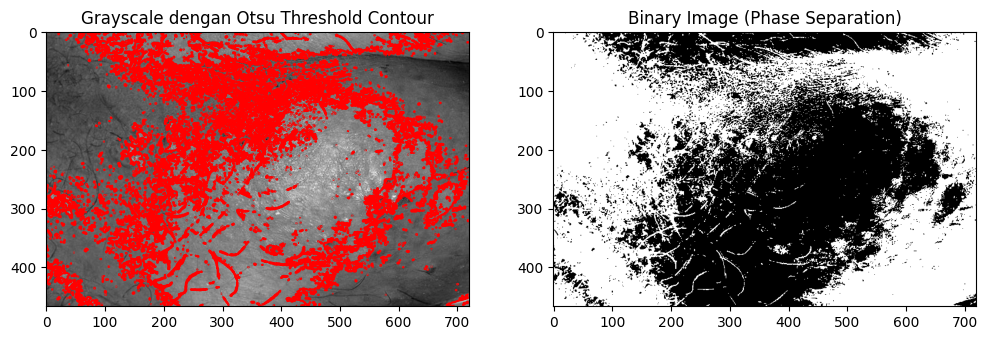

In [151]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 8))

ax[0].imshow(grayscale_uint8, cmap='gray')
ax[0].contour(grayscale_uint8, [threshold], colors='r')
ax[0].set_title("Grayscale dengan Otsu Threshold Contour")
ax[1].imshow(phase_separation, cmap='gray')
ax[1].set_title("Binary Image (Phase Separation)")

plt.show()

In [155]:
median_filtered = filters.median(phase_separation, footprint=np.ones((7, 7)))

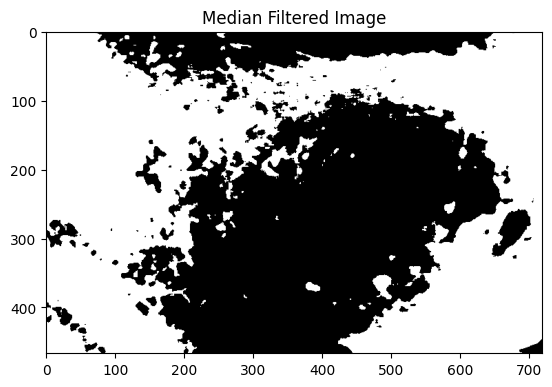

In [156]:
plt.imshow(median_filtered, cmap='gray')
plt.title("Median Filtered Image")
plt.show()

In [158]:
print(phase_separation.shape)

row_center = phase_separation.shape[0] // 2
col_center = phase_separation.shape[1] // 2
row_start = max(0, row_center - 10)
row_end = min(phase_separation.shape[0], row_center + 10)
col_start = max(0, col_center - 10)
col_end = min(phase_separation.shape[1], col_center + 10)

(467, 720)


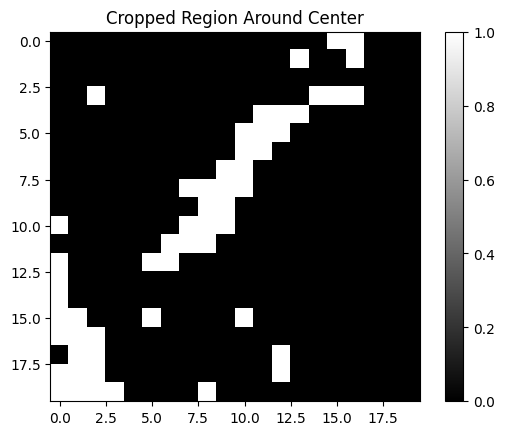

In [159]:
plt.imshow(phase_separation[row_start:row_end, col_start:col_end], cmap='gray')
plt.colorbar()
plt.title("Cropped Region Around Center")
plt.show()

In [160]:
print(f"Standard deviation of cropped region: {phase_separation[row_start:row_end, col_start:col_end].std()}")

Standard deviation of cropped region: 0.34437443284889785


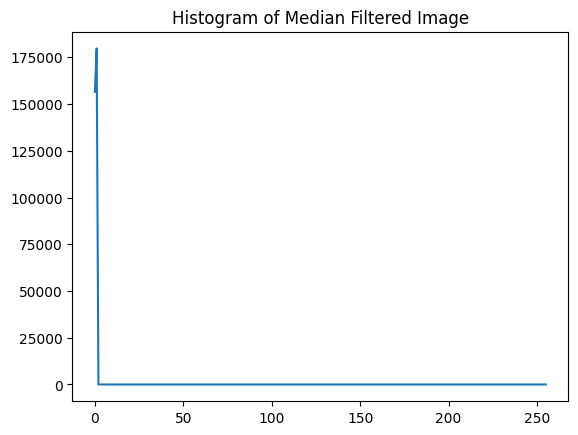

In [165]:
histo_median = ndi.histogram(median_filtered, min=0, max=255, bins=256)
plt.plot(histo_median)
plt.title("Histogram of Median Filtered Image")
plt.show()

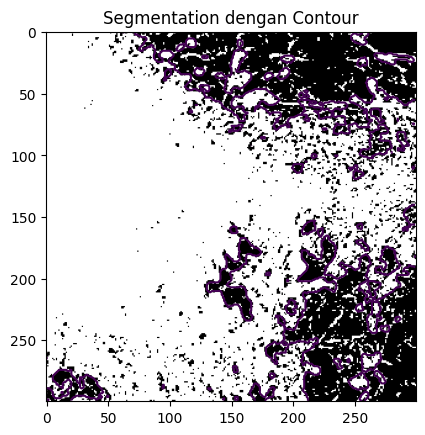

In [169]:
threshold2 = filters.threshold_otsu(median_filtered)
plt.imshow(phase_separation[:300, :300], cmap='gray')
plt.contour(median_filtered[:300, :300], [threshold2])
plt.title("Segmentation dengan Contour")
plt.show()

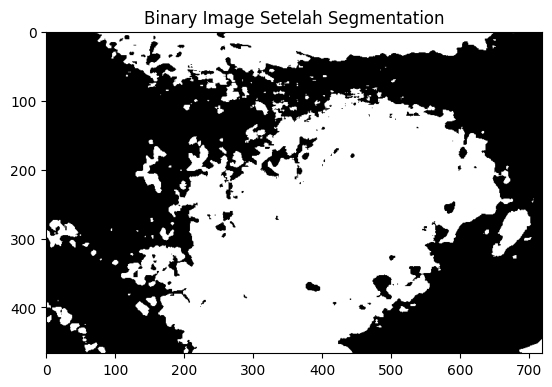

In [170]:
binary_image = median_filtered < filters.threshold_otsu(median_filtered)
plt.imshow(binary_image, cmap='gray')
plt.title("Binary Image Setelah Segmentation")
plt.show()

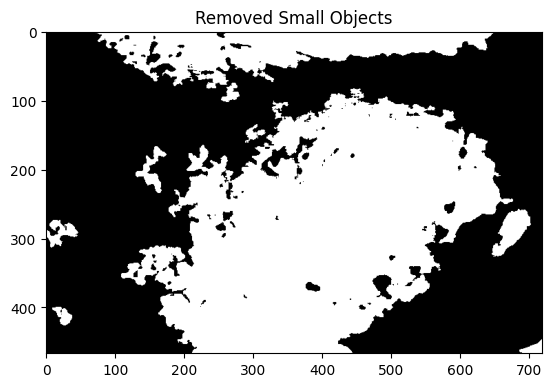

In [171]:
only_large_blobs = morphology.remove_small_objects(binary_image, min_size=300)
plt.imshow(only_large_blobs, cmap='gray')
plt.title("Removed Small Objects")
plt.show()


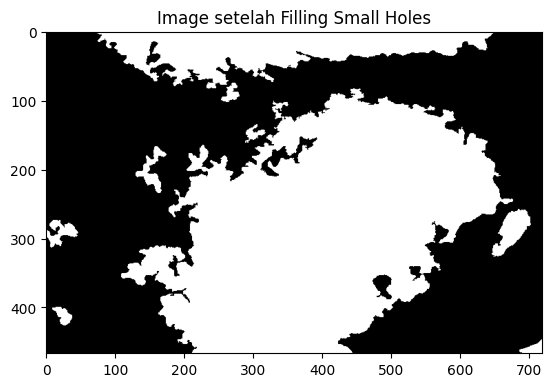

In [175]:
only_large = np.logical_not(morphology.remove_small_objects(np.logical_not(only_large_blobs), min_size=300))
image_segmented = only_large
plt.imshow(image_segmented, cmap='gray')
plt.title("Image setelah Filling Small Holes")
plt.show()

In [176]:
labels, nlabels = ndi.label(image_segmented)

print(f'There are {nlabels} separate components / objects detected.')

There are 9 separate components / objects detected.


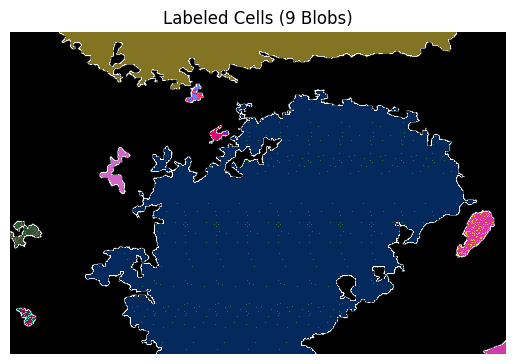

In [177]:
rand_cmap = ListedColormap(np.random.rand(256, 3))
labels_for_display = np.where(labels > 0, labels, np.nan)
plt.imshow(image_segmented, cmap='gray')
plt.imshow(labels_for_display, cmap=rand_cmap)
plt.axis('off')
plt.title(f'Labeled Cells ({nlabels} Blobs)')
plt.show()

In [181]:
boxes = ndi.find_objects(labels)
for label_ind, label_coords in enumerate(boxes):
  cell = image_segmented[label_coords]
  if np.product(cell.shape) < 2000:
    print(f'Label {label_ind} is too small! Setting to 0.')
    image_segmented = np.where(labels == label_ind + 1, 0, image_segmented)

In [182]:
labels, nlabels = ndi.label(image_segmented)

print(f'There are now {nlabels} separate components / objects detected.')

There are now 4 separate components / objects detected.


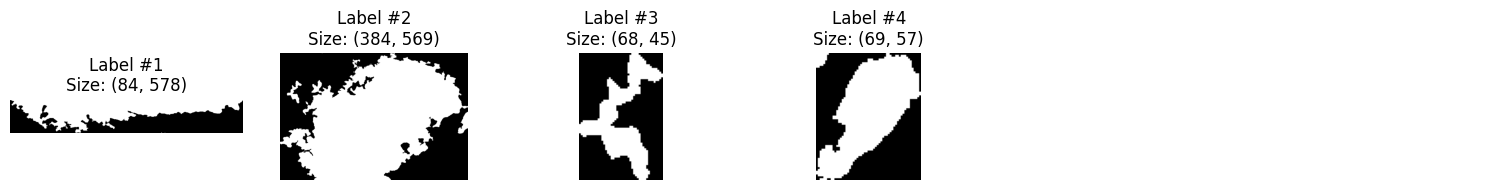

In [186]:
labels, nlabels = ndi.label(image_segmented)

num_objects = nlabels
ncols = 6
nrows = int(np.ceil(num_objects / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 2))
axes = axes.flatten()

for i, obj_indices in enumerate(ndi.find_objects(labels)):
    if obj_indices is not None:
        cell = image_segmented[obj_indices]
        axes[i].imshow(cell, cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f'Label #{i+1}\nSize: {cell.shape}')
    else:
        axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [187]:
label_img = label(image_segmented)
regions = regionprops(label_img)

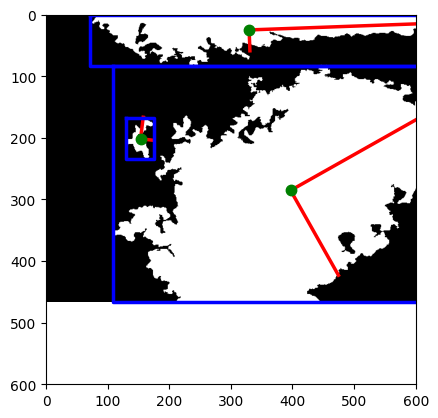

In [188]:
fig, ax = plt.subplots()
ax.imshow(image_segmented, cmap=plt.cm.gray)
for props in regions:
    y0, x0 = props.centroid
    orientation = props.orientation
    x1 = x0 + math.cos(orientation) * 0.5 * props.minor_axis_length
    y1 = y0 - math.sin(orientation) * 0.5 * props.minor_axis_length
    x2 = x0 - math.sin(orientation) * 0.5 * props.major_axis_length
    y2 = y0 - math.cos(orientation) * 0.5 * props.major_axis_length
    ax.plot((x0, x1), (y0, y1), '-r', linewidth=2.5)
    ax.plot((x0, x2), (y0, y2), '-r', linewidth=2.5)
    ax.plot(x0, y0, '.g', markersize=15)
    minr, minc, maxr, maxc = props.bbox
    bx = (minc, maxc, maxc, minc, minc)
    by = (minr, minr, maxr, maxr, minr)
    ax.plot(bx, by, '-b', linewidth=2.5)
ax.axis((0, 600, 600, 0))
plt.show()


In [190]:
props = regionprops_table(label_img, properties=('centroid', 'orientation', 'major_axis_length', 'minor_axis_length'))
df1 = pd.DataFrame(props)

print(df1)

   centroid-0  centroid-1  orientation  major_axis_length  minor_axis_length
0   24.757955  329.623177    -1.534559         586.039872          67.804224
1  285.317980  396.942410    -1.057351         530.225802         316.082555
2  201.354774  153.331658    -0.123353          70.091504          36.830049
3  289.001042  675.789583    -0.585546          80.264152          33.341529


In [191]:
print(df1.describe())

       centroid-0  centroid-1  orientation  major_axis_length  \
count    4.000000    4.000000     4.000000           4.000000   
mean   200.107938  388.921707    -0.825202         316.655332   
std    123.709210  217.084083     0.607483         279.794500   
min     24.757955  153.331658    -1.534559          70.091504   
25%    157.205569  285.550298    -1.176653          77.720990   
50%    243.336377  363.282793    -0.821449         305.244977   
75%    286.238745  466.654203    -0.469998         544.179319   
max    289.001042  675.789583    -0.123353         586.039872   

       minor_axis_length  
count           4.000000  
mean          113.514589  
std           135.930689  
min            33.341529  
25%            35.957919  
50%            52.317137  
75%           129.873807  
max           316.082555  


In [192]:
df1.shape

(4, 5)

In [193]:
df1.columns

Index(['centroid-0', 'centroid-1', 'orientation', 'major_axis_length',
       'minor_axis_length'],
      dtype='object')

In [194]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   centroid-0         4 non-null      float64
 1   centroid-1         4 non-null      float64
 2   orientation        4 non-null      float64
 3   major_axis_length  4 non-null      float64
 4   minor_axis_length  4 non-null      float64
dtypes: float64(5)
memory usage: 288.0 bytes


In [195]:
df1.describe()

,centroid-0,centroid-1,orientation,major_axis_length,minor_axis_length
count,4.000000,4.000000,4.000000,4.000000,4.000000
mean,200.107938,388.921707,-0.825202,316.655332,113.514589
std,123.709210,217.084083,0.607483,279.794500,135.930689
min,24.757955,153.331658,-1.534559,70.091504,33.341529
25%,157.205569,285.550298,-1.176653,77.720990,35.957919
50%,243.336377,363.282793,-0.821449,305.244977,52.317137
75%,286.238745,466.654203,-0.469998,544.179319,129.873807
max,289.001042,675.789583,-0.123353,586.039872,316.082555


In [196]:
df1.isnull().sum().sort_values(ascending=False)

,0
centroid-0,0
centroid-1,0
orientation,0
major_axis_length,0
minor_axis_length,0
